# MNIST (Modified National Institute of Standards and Technology)

O que é o MNIST?

* O conteúdo: 70.000 imagens em escala de cinza de dígitos manuscritos (números de 0 a 9).
* Dimensões de cada imagem: $28 \times 28$ pixels.
* Valores dos pixels: Números inteiros de 0 a 255, onde $0$ é o fundo preto (ou branco, dependendo da escala) e $255$ é o traço mais forte da caneta.

O ML Clássico:

* Modelos clássicos (como SVM, KNN, Random Forest ou Regressão Logística) não entendem matrizes 2D de imagem.
* Por isso, cada imagem de $28 \times 28$ é "achatada" (flatten) em uma linha com 784 colunas ($28 \times 28 = 784$ variáveis numéricas).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
# Baixando o MNIST oficial do OpenML (vai demorar um pouco pessoal)
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


https://www.openml.org/search?type=data&sort=runs&id=554&status=active

In [3]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

In [4]:
X[700]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  98, 224,  42,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  3

In [5]:
X.shape

(70000, 784)

In [6]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [7]:
# Como o target vem como string ('0', '1', ...), eu vou converter para inteiros
y = y.astype(np.uint8)

In [8]:
print(f"Formato de X (amostras, pixels por imagem): {X.shape}") # (70000, 784)
print(f"Formato de y (rótulos): {y.shape}")                     # (70000,)
print(f"Classes únicas existentes: {np.unique(y)}")

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]


<br>
<br>

# Vamos visualizar os Dígitos

Na Prática para desenharmos a imagem, pegamos o vetor de 784 números e fazemos o processo inverso: transformamos de volta em uma matriz $28 \times 28$ com o .reshape(28, 28).

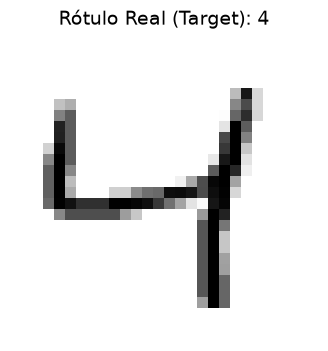

In [11]:
# Podemos escolher uma imagem aleatória (sei lá, por exemplo o índice 1)
digito_exemplo = X[2]
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[2]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

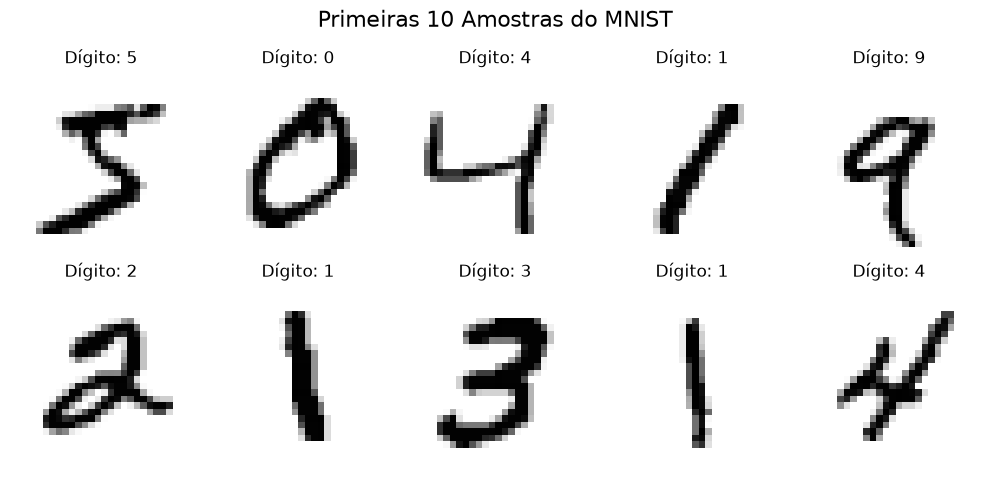

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    # Remodela a i-ésima imagem para 28x28
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Dígito: {y[i]}")
    ax.axis('off')

plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=16)
plt.tight_layout()
plt.show()

<br>
<br>

# Vamos pegar um modelo de ML classíco

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html

*Gemini*

O SGDClassifier do Scikit-learn é um estimador que implementa classificadores lineares otimizados por Descida de Gradiente Estocástica (Stochastic Gradient Descent - SGD).

### Como o SGDClassifier Funciona

**Atualização por amostra:** Em vez de calcular o gradiente do erro usando o conjunto de dados inteiro de uma só vez (o que é custoso para bases gigantes), o SGD estima o gradiente processando os dados uma amostra por vez (ou em pequenos lotes/minibatches).  

**Função de Perda (loss):** O parâmetro loss define qual modelo linear será treinado. Por padrão, ele usa loss="hinge", o que resulta em um classificador SVM linear (Support Vector Machine). Se você alterar para loss="log_loss", ele funciona como uma Regressão Logística.  

**Taxa de Aprendizado (learning_rate):** Os pesos do modelo são atualizados passo a passo usando uma taxa de aprendizado decrescente ao longo das iterações.  

**Aprendizado Online(partial_fit):** Como o modelo aprende incrementalmente, você pode usar o método partial_fit para treinar com dados que chegam em tempo real ou que são grandes demais para caber na memória RAM.

<br>
<br>

# Primeiro Experimento Clássico: Classificação Binária ("É o número 5 ou não?")

In [13]:
# Biblioteca
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [15]:
# Divisão Treino e Teste (usando uma fatia menor)
# O padrão oficial do MNIST (site) são as primeiras 60.000 para treino e as 10.000 finais para teste
# X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
# Garante que a proporção das classes nos dados originais seja mantida exatamente igual tanto no conjunto de treino (y_train) quanto no de teste (y_test).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Criando o target binário: True para 5, False para qualquer outro dígito
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [17]:
y_train_5

array([False, False, False, ..., False, False, False], shape=(56000,))

In [18]:
# Treinando classificador linear clássico (SGD - Stochastic Gradient Descent)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [19]:
# Testando a previsão na primeira imagem (que sabemos ser um 5)
print(f"Previsão para o primeiro dígito: {sgd_clf.predict([X[0]])}") # Retorna [True]

Previsão para o primeiro dígito: [ True]


In [20]:
# 5. Avaliando no conjunto de teste
y_pred_5 = sgd_clf.predict(X_test)

In [21]:
print("\nMatriz de Confusão ('Detector de 5')")
print(confusion_matrix(y_test_5, y_pred_5))


Matriz de Confusão ('Detector de 5')
[[12648    89]
 [  453   810]]


In [22]:
print("\nRelatório de Métricas")
print(classification_report(y_test_5, y_pred_5, target_names=['Não é 5', 'É 5']))


Relatório de Métricas
              precision    recall  f1-score   support

     Não é 5       0.97      0.99      0.98     12737
         É 5       0.90      0.64      0.75      1263

    accuracy                           0.96     14000
   macro avg       0.93      0.82      0.86     14000
weighted avg       0.96      0.96      0.96     14000



* Para o computador não existe "desenho". Existem apenas 784 sensores de luz medindo a intensidade da tinta de 0 a 255.   
  
* Apenas cerca de 10% das imagens são o número 5, um modelo preguiçoso que sempre chuta "Não é 5" acertaria 90% das vezes. Por isso, é importante se atentar as métricas (Precisão, Recall e a Matriz de Confusão).   

* Métodos clássicos tratam o pixel $1$ e o pixel $784$ como variáveis isoladas, ignorando a vizinhança geométrica espacial. Aqui um algoritmo de Redes Neurais Convolucionais (CNNs), poderia ter uma performance muito interessante.